<a href="https://colab.research.google.com/github/genaiconference/Agentic_KAG_Workshop_DHS_2026/blob/main/01_construct_knowledge_graph_SimpleKGPipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎓 Knowledge Graph Construction: Unstructured PDF to Neo4j

Welcome to this hands-on guide! In this notebook, we will explore how to bridge the gap between unstructured text and structured intelligence.

### 🎯 Learning Objectives
- Understand the difference between **Lexical Graphs** (text structure) and **Domain Graphs** (semantic meaning).
- Learn to use the **Neo4j GraphRAG Python SDK** to automate graph construction with **SimpleKGPipeline** package
- Connect document provenance to extracted facts for transparent RAG systems.

### 🛠️ Tech Stack
- **Neo4j**: The graph database for storing and querying our knowledge.
- **OpenAI (GPT-5-mini / Text-Embeddings)**: The 'brain' used for understanding text and generating vectors.
- **Neo4j GraphRAG SDK**: A high-level library that simplifies the pipeline from PDF to Graph.

### 💡 Key Takeaways
By the end of this tutorial, you will have a live Knowledge Graph generated from an HR policy document, allowing you to query not just 'where' a word is mentioned, but 'how' entities are related across your entire document library.

# Building a Knowledge Graph from an Unstructured PDF with Neo4j SimpleKGPipeline

This notebook demonstrates how to turn an **unstructured PDF document** — `Leave_Policy.pdf` — into a **knowledge graph** using Neo4j GraphRAG's [`SimpleKGPipeline`](https://neo4j.com/docs/neo4j-graphrag-python/current/user_guide_kg_builder.html).

The pipeline automatically produces two complementary graphs:

| Graph | What it captures | Node labels |
|-------|------------------|-------------|
| **Lexical graph** | The physical structure of the text | `Document`, `Chunk` |
| **Domain graph** | The *meaning* extracted from the text | `Policy`, `LeaveType`, `Employee`, `Eligibility`, ... |


> This showcases the shift from *document-centric* retrieval to *graph-powered reasoning* over unstructured HR policy content.

### ⚙ Pipeline Architecture of SimpleKGPipeline

Below is a visual representation of how the `SimpleKGPipeline` processes your document in the background:



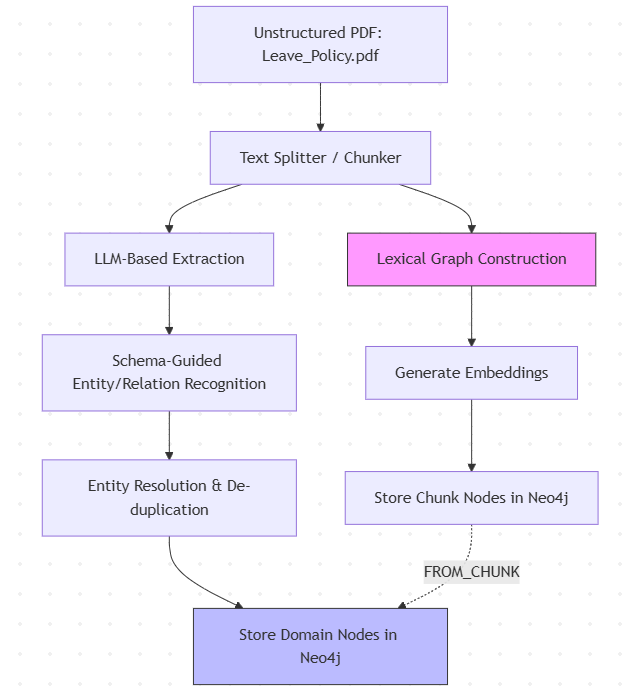



**Note on Interconnectivity:**
Every entity in the **Domain Graph** (e.g., a specific Leave Type) maintains a link back to the specific **Chunk** in the **Lexical Graph** it was extracted from. This ensures full transparency and 'grounding' for any RAG application.

In [ ]:
!git clone https://github.com/genaiconference/Agentic_KAG_Workshop_DHS_2026.git

Upload your '.env' file inside the 'Agentic_KAG_Workshop_DHS_2026' folder in the Files section

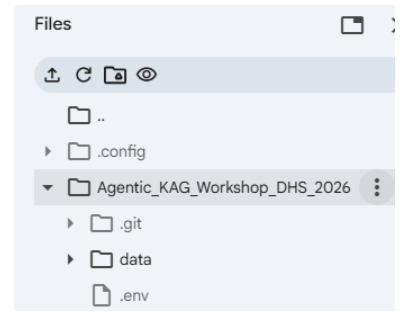

## 1. Install Required Packages

To build our Knowledge Graph, we need several specialized libraries:
- **`neo4j-graphrag[openai]`**: This is the core SDK that provides the `SimpleKGPipeline`. The `[openai]` extra ensures we have the necessary dependencies to communicate with OpenAI's models.
- **`neo4j`**: The official driver used to communicate with our graph database.
- **`pypdf`**: A library that allows Python to read and parse PDF files. The pipeline uses this to extract raw text from our document.
- **`python-dotenv`**: A best-practice tool for loading environment variables (like API keys) from a `.env` file rather than hardcoding them in the notebook.

In [1]:
%pip install -U "neo4j-graphrag[openai]" neo4j pypdf python-dotenv pandas --quiet

## 2. Import Required Libraries

We import the Neo4j driver plus the GraphRAG building blocks: `SimpleKGPipeline`, an `OpenAILLM` for extraction and `OpenAIEmbeddings` for the lexical graph vectors.

In [2]:
import os
import asyncio
from pathlib import Path

import pandas as pd
from dotenv import load_dotenv
from neo4j import GraphDatabase

from neo4j_graphrag.llm import OpenAILLM
from neo4j_graphrag.embeddings import OpenAIEmbeddings
from neo4j_graphrag.experimental.pipeline.kg_builder import SimpleKGPipeline

print("Libraries imported successfully")

Libraries imported successfully


## 3. Configure Environment Variables and Credentials

Credentials are loaded from the local `.env` file in this folder (Neo4j URI/user/password and the OpenAI API key). Update the fallback values below if you are pointing at a different Neo4j instance.

In [3]:
# Load variables from the local .env (if present)
import os

os.chdir('/content/Agentic_KAG_Workshop_DHS_2026/')
load_dotenv()

# ---- Neo4j connection ----
NEO4J_URI      = os.getenv("NEO4J_URI")
NEO4J_USERNAME = os.getenv("NEO4J_USERNAME")
NEO4J_PASSWORD = os.getenv("NEO4J_PASSWORD")
NEO4J_DATABASE = os.getenv("NEO4J_DATABASE")

# --- OpenAI ---
os.environ.setdefault(
    'OPENAI_API_KEY',
    os.getenv('OPENAI_API_KEY')
)

print("Neo4j URI     :", NEO4J_URI)
print("Neo4j database:", NEO4J_DATABASE)
print("OpenAI key set:", bool(os.getenv("OPENAI_API_KEY")))

Neo4j URI     : bolt://54.175.94.104
Neo4j database: neo4j
OpenAI key set: True


## 4. Connect to Neo4j Database

Create the driver and verify connectivity before running the pipeline. We also define a small `run_query` helper used throughout the notebook.

In [4]:
# check Neo4j connection
neo4j_driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USERNAME, NEO4J_PASSWORD))
neo4j_driver.verify_connectivity()
print("Connected to Neo4j")

Connected to Neo4j


## 5. Load the PDF Document

Point to `Leave_Policy.pdf` in the AV2026 folder, confirm the file exists, and peek at the first page of extracted text so we can see the unstructured content the pipeline will process.

In [5]:
from pypdf import PdfReader

PDF_PATH = Path("/content/Agentic_KAG_Workshop_DHS_2026/data/Leave_Policy.pdf")
assert PDF_PATH.exists(), f"File not found: {PDF_PATH}"

reader = PdfReader(str(PDF_PATH))
print(f"File: {PDF_PATH.name}")
print(f"Number of pages: {len(reader.pages)}")

File: Leave_Policy.pdf
Number of pages: 7


## 6. Initialize the LLM and Embedder

- The **LLM** (`gpt-5-mini`) reads each text chunk and extracts entities & relationships as JSON.
- The **embedder** (`text-embedding-3-small`) converts every chunk into a vector, which becomes a property on the `Chunk` nodes of the lexical graph (enabling vector search later).

In [6]:
llm = OpenAILLM(
    model_name="gpt-5-mini",
    model_params={
        "response_format": {"type": "json_object"},
    },
)

embedder = OpenAIEmbeddings(model="text-embedding-3-small")

print("LLM and embedder configured")

LLM and embedder configured


## 7. Build the SimpleKGPipeline

The simplest way to begin building a KG from unstructured data using this package is utilizing the SimpleKGPipeline interface



---


We configure `SimpleKGPipeline` with
- `from_file=True` so it reads the PDF directly, chunks it, embeds each chunk (lexical graph), and runs schema-guided entity extraction (domain graph). `perform_entity_resolution=True` merges duplicate entities that the LLM extracts across chunks.

**Schema Extraction Modes**

`EXTRACTED` (Default): Automatically generates a schema from the input using an LLM and applies it consistently across all chunks, ensuring uniform entity and relationship extraction.

`FREE`: Skips schema generation and performs unrestricted entity and relationship extraction directly from the text without predefined guidance.

In [11]:
kg_builder = SimpleKGPipeline(  llm=llm,                       # an LLMInterface for Entity and Relation extraction
                                driver=neo4j_driver,           # a neo4j driver to write results to graph
                                embedder=embedder,              # an Embedder for chunks
                                neo4j_database=NEO4J_DATABASE,  # writes to a specific Neo4j database
                                schema="FREE",                  # change to schema="EXTRACTED" for auto schema extraction
                                from_file=True,                      # read the PDF directly -> builds the lexical graph - # set to False if parsing an already extracted text
                                perform_entity_resolution=True,      # merge duplicate extracted entities
                                on_error="IGNORE",
                              )

print("SimpleKGPipeline configured (from_pdf=True)")

SimpleKGPipeline configured (from_pdf=True)


## 9. Run the Pipeline on the PDF

Running the pipeline is asynchronous. In a Jupyter notebook we can simply `await` the coroutine. This step extracts chunks, embeds them, extracts entities/relationships, and writes everything to Neo4j.

This step takes upto a minute to run ... patience is key :)

In [12]:
# Run Pipeline

result = await kg_builder.run_async(file_path=str(PDF_PATH))  # await kg_builder.run_async(text="my text")  # if using from_file=False
print("Pipeline finished")
print(result)

Pipeline finished
run_id='a534a2dd-e52b-4209-9e97-e113b4e37cd0' result={'resolver': {'number_of_nodes_to_resolve': 58, 'number_of_created_nodes': 47}}


## 10. Visualize the Knowledge Graph

You can explore the full graph visually in **Neo4j Browser / Bloom / Workspace**.

We have created a **lexical graph** (Document → Chunks) alongside the **domain graph** (entities), plus the `FROM_CHUNK` edges that link an entity back to the chunk it was extracted from.


---



#### Step-1 : Open the Visualization Workspace

1. Visit https://sandbox.neo4j.com/
2. Click on **"Open"** Dropdown
3. Select **"Open with Workspace"**
4. Enter your sandbox credentials **"Database user" & "Password"** and click **"Connect"**



---



#### Step-2 : Run a Query to Visualize the Graph

1. Locate the editor command line text box at the top of the main screen area.

2. Copy and paste the following standard Cypher queries into the input field one by one

**Visualize entire graph**

```
MATCH (n)-[r]->(m) RETURN n, r, m
```

**Visualize the Schema**



```
CALL db.schema.visualization()
```

---


#### Step -3: Interact with Your Visualized Graph

**Expand Nodes:** Double-click any circle on the screen to automatically fetch and display all neighboring connected nodes.

**View Properties:** Click once on any node or relationship line to view its complete key-value metadata in the properties panel at the bottom of the interface.

**Rearrange Layout:** Click and hold down your mouse on any node to manually drag it around and re-organize the layout for better readability.

**Change Colors:** Click on any node label tab displayed at the very top of your visualization window to change the size, color, or text display property of those specific nodes.





## Summary

Starting from a single **unstructured PDF** (`Leave_Policy.pdf`), Neo4j GraphRAG's `SimpleKGPipeline` automatically produced:

- a **lexical graph** — `Document` and `Chunk` nodes with vector embeddings, capturing the text structure, and
- a **domain graph** — `LeaveType`, `Eligibility`, `Duration`, `Approver`, `Condition` entities and their relationships, capturing the *meaning*.

The two graphs are stitched together through `FROM_CHUNK` edges, giving every extracted fact full **provenance** back to its source text. This foundation supports GraphRAG retrieval that reasons over connected policy knowledge instead of isolated text chunks.

Finally, close the driver to release the connection.

## 11. Delete the Graph (Cleanup)

Run the cell below to remove **all nodes and relationships** from the database — useful for resetting between demo runs. This is destructive and cannot be undone.

In [10]:
# WARNING: this deletes ALL nodes and relationships in the database.
# Re-open a driver in case it was closed in the previous cell.
driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USERNAME, NEO4J_PASSWORD))

# Define run_query helper function
def run_query(query):
    with driver.session(database=NEO4J_DATABASE) as session:
        return session.run(query).data()

with driver.session(database=NEO4J_DATABASE) as session:
    session.run("MATCH (n) DETACH DELETE n")

# Confirm the graph is empty
remaining = run_query("MATCH (n) RETURN count(n) AS node_count")
print("Graph deleted. Remaining nodes:", remaining[0]["node_count"])

driver.close()
print("Neo4j driver closed")

Graph deleted. Remaining nodes: 0
Neo4j driver closed
